Цель работы: изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

Постановка задачи:
Провести обучение модели линейной регрессии на датасете с Kaggle:
1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).
2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. 
3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально), нормализовать признаки.
4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
5. Построить регрессионные модели (линейная и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).
7. Повторить шаг 5 (линейная и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

Датасет - Цены на жилье в Калифорнии (California Housing Prices)

Целевая переменная - Средняя стоимость дома в пределах квартала (median_house_value)

Признаки:
1. longitude - мера того, насколько далеко к западу находится дом (чем больше, тем дальше на запад)
2. latitude - мера того, насколько далеко на севере находится дом (чем больше, тем дальше на север)
3. housing_median_age - средний возраст дома в квартале
4. total_rooms - общее количество комнат
5. population - общее количество людей, проживающих в пределах квартала
6. households - общее количество домохозяйств
7. median_income - средний доход домохозяйств в пределах жилого квартала

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv("housing.csv")
df_selected = df[["longitude","latitude","housing_median_age","total_rooms","population","households","median_income","median_house_value"]]
df_selected.head()


,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,565.0,259.0,3.8462,342200.0


In [ ]:
print("Первичный анализ:")

summary = pd.DataFrame({
    "Среднее": df_selected.mean(numeric_only=True),
    "Медиана": df_selected.median(numeric_only=True),
    "Мода": df_selected.mode().iloc[0],
    "Ст. отклонение": df_selected.std(numeric_only=True)
})

print(summary)

Первичный анализ:
                          Среднее      Медиана        Мода  Ст. отклонение
longitude             -119.569704    -118.4900    -118.310        2.003532
latitude                35.631861      34.2600      34.060        2.135952
housing_median_age      28.639486      29.0000      52.000       12.585558
total_rooms           2635.763081    2127.0000    1527.000     2181.615252
population            1425.476744    1166.0000     891.000     1132.462122
households             499.539680     409.0000     306.000      382.329753
median_income            3.870671       3.5348       3.125        1.899822
median_house_value  206855.816909  179700.0000  500001.000   115395.615874


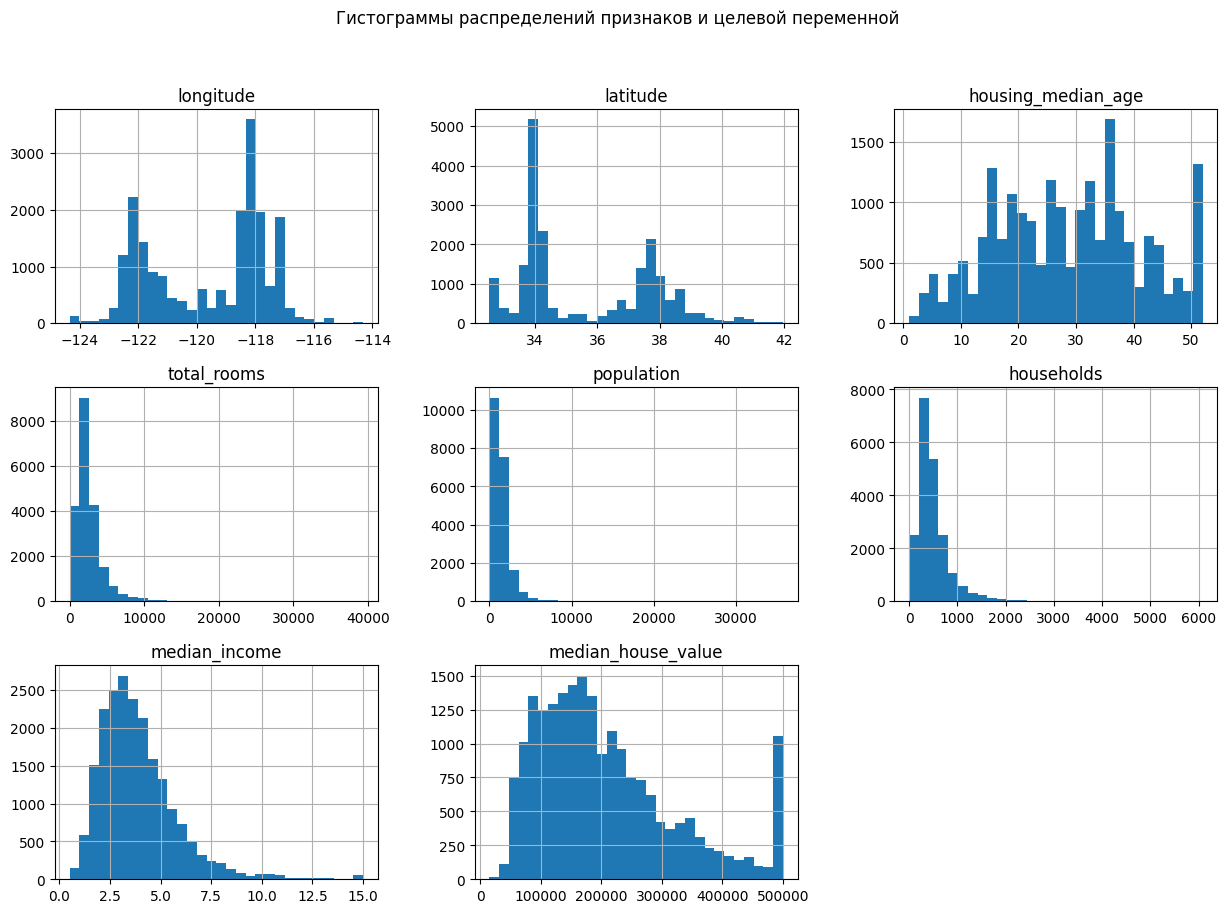

In [46]:
df_selected.hist(bins=30, figsize=(15, 10))
plt.suptitle("Гистограммы распределений признаков и целевой переменной")
plt.show()

In [54]:
print('Количество пропущенных значений:\n',df_selected.isnull().sum())

Количество пропущенных значений:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Класс для нормализации данных
scaler = StandardScaler()
# Признаки
features = ["longitude","latitude","housing_median_age","total_rooms","population","households","median_income"]
# fit - вычисляет среднее и стандартное отклонение каждого признака, transform — применяет формулу стандартизации
X_scaled = scaler.fit_transform(df_selected[features])
df_scaled = pd.DataFrame(X_scaled, columns=features)
print("Данные после нормализации:")
print(df_scaled.head())

Данные после нормализации:
   longitude  latitude  housing_median_age  total_rooms  population  \
0  -1.327835  1.052548            0.982143    -0.804819   -0.974429   
1  -1.322844  1.043185           -0.607019     2.045890    0.861439   
2  -1.332827  1.038503            1.856182    -0.535746   -0.820777   
3  -1.337818  1.038503            1.856182    -0.624215   -0.766028   
4  -1.337818  1.038503            1.856182    -0.462404   -0.759847   

   households  median_income  
0   -0.977033       2.344766  
1    1.669961       2.332238  
2   -0.843637       1.782699  
3   -0.733781       0.932968  
4   -0.629157      -0.012881  


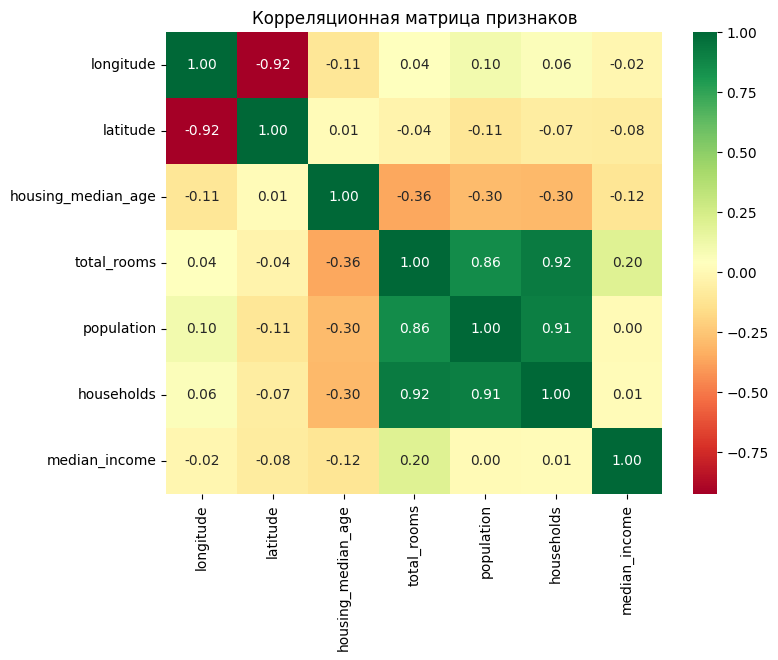


Коэффициенты VIF:
              Признак        VIF
0           longitude   8.676792
1            latitude   8.822954
2  housing_median_age   1.257710
3         total_rooms   9.529851
4          population   5.931996
5          households  11.620159
6       median_income   1.523985


In [56]:
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

vif_data = pd.DataFrame()
vif_data["Признак"] = df_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print("\nКоэффициенты VIF:")
print(vif_data)

longitude и latitude сильно коррелированы (-0.92), т.к. это признаки географического положения, которые "дублируют" информацию.

total_rooms, population, households образуют «кластер» с очень высокой корреляцией (0.86–0.92), т.к. где больше населения, там больше домохозяйств и комнат.

housing_median_age и median_income почти не коррелируют с другими признаками.

housing_median_age и median_income независимы, т.к. VIF для них меньше 5. Остальные мультиколлинеарны.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# Расчет метрик - RMSE, R2, MAPE
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    return {"RMSE": rmse, "R2": r2, "MAPE (%)": mape}

def run_models(X, y, dataset_name):
    # Разделение на тренировочную и тестовую выборки (20% данных в тестовую, 80% для обучения)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    models = {
        "Линейная регрессия": LinearRegression(),
        "Гребневая регрессия": Ridge(alpha=1.0)
    }
    
    results = []
    for name, model in models.items():
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
        # Кросс-валидация
        cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
        metrics["R2_CV_mean"] = cv_scores.mean()
        metrics["R2_CV"] = np.round(cv_scores, 6)
        
        results.append({"Модель": name, "Набор данных": dataset_name, **metrics})
    
    return pd.DataFrame(results)

results_scaled = run_models(df_scaled, df_selected["median_house_value"], "До PCA")
print(results_scaled)

                Модель Набор данных          RMSE        R2   MAPE (%)  \
0   Линейная регрессия       До PCA  70517.833856  0.620518  31.005050   
1  Гребневая регрессия       До PCA  70517.930211  0.620517  31.004587   

   R2_CV_mean                                              R2_CV  
0    0.580024  [0.579794, 0.516077, 0.578409, 0.533676, 0.692...  
1    0.580027  [0.57985, 0.516046, 0.578433, 0.533653, 0.692156]  


Данные до PCA: (20640, 7)
Данные после PCA: (20640, 4)
Доля объяснённой дисперсии по компонентам: [0.42745758 0.27081083 0.15019421 0.11673513]
Суммарно объясняется: 0.965197749911434


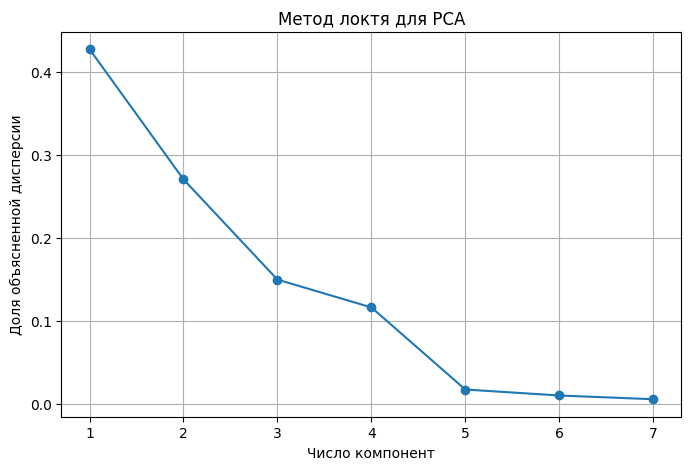

In [115]:
from sklearn.decomposition import PCA

X = df_scaled
pca = PCA(n_components=0.95)  
X_pca = pca.fit_transform(X)

print("Данные до PCA:", X.shape)
print("Данные после PCA:", X_pca.shape)

explained_var = pca.explained_variance_ratio_
print("Доля объяснённой дисперсии по компонентам:", explained_var)
print("Суммарно объясняется:", explained_var.sum())
pca_full = PCA().fit(X)

plt.figure(figsize=(8,5))
explained_variance_ratio = pca_full.explained_variance_ratio_
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.xlabel("Число компонент")
plt.ylabel("Доля объясненной дисперсии")
plt.title("Метод локтя для PCA")
plt.grid(True)
plt.show()

In [113]:
results_pca = run_models(X_pca, df_selected["median_house_value"], "После PCA")
print(results_pca)

                Модель Набор данных          RMSE        R2   MAPE (%)  \
0   Линейная регрессия    После PCA  80048.600169  0.511009  36.803314   
1  Гребневая регрессия    После PCA  80048.488668  0.511011  36.804089   

   R2_CV_mean                                              R2_CV  
0    0.462911  [0.494024, 0.40272, 0.492226, 0.381702, 0.543883]  
1    0.462910  [0.494019, 0.402736, 0.492226, 0.381693, 0.543...  


In [109]:
comparison_df = pd.concat([results_scaled, results_pca], ignore_index=True)
print("Сравнение моделей до и после PCA:")
print(comparison_df)

Сравнение моделей до и после PCA:
                Модель Набор данных          RMSE        R2   MAPE (%)  \
0   Линейная регрессия       До PCA  70517.833856  0.620518  31.005050   
1  Гребневая регрессия       До PCA  70517.930211  0.620517  31.004587   
2   Линейная регрессия    После PCA  80048.600169  0.511009  36.803314   
3  Гребневая регрессия    После PCA  80048.488668  0.511011  36.804089   

   R2_CV_mean                                       R2_CV_scores  
0    0.580024  [0.5797936758690057, 0.5160773693354495, 0.578...  
1    0.580027  [0.579849689193914, 0.5160455192961059, 0.5784...  
2    0.462911  [0.49402432823878817, 0.40272026057579535, 0.4...  
3    0.462910  [0.49401876702494574, 0.40273636190614825, 0.4...  


Линейная и гребневая регрессии показали практически одинаковые результаты, значит, мультиколлинеарность в данных либо слабо выражена, либо регуляризация с альфа=1 была недостаточной для улучшения качества.

Применение PCA ухудшило качество моделей как линейной, так и гребневой регрессии по всем трем метрикам: значение RMSE увеличилось с 70 до 80 тыс, значение R2 снизилось с 62 до 51%, ошибка MAPE выросла с 31 до 37%. Таким образом, применение PCA привело к существенному ухудшению прогностической способности моделей.

Удовлетворительной считается значение MAPE <= 20%, но во всех случаях оно превышает данный порог, что говорит о недостаточной точности для практического применения.